In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_students = 100

data = {
    "Student_ID": [f"S{i:03d}" for i in range(1, n_students + 1)],
    "Watch_Time": np.random.randint(10, 100, n_students),
    "Completion_Rate": np.random.randint(20, 100, n_students),
    "Replays": np.random.randint(0, 8, n_students),
    "Pauses": np.random.randint(0, 10, n_students),
    "Videos_Watched": np.random.randint(1, 15, n_students),
    "Quiz_Score": np.random.randint(30, 100, n_students)
}

df = pd.DataFrame(data)

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
0,S001,61,90,1,7,9,39
1,S002,24,28,7,3,10,98
2,S003,81,20,5,2,14,63
3,S004,70,27,7,8,13,81
4,S005,30,82,6,2,6,39


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student_ID       100 non-null    object
 1   Watch_Time       100 non-null    int64 
 2   Completion_Rate  100 non-null    int64 
 3   Replays          100 non-null    int64 
 4   Pauses           100 non-null    int64 
 5   Videos_Watched   100 non-null    int64 
 6   Quiz_Score       100 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 5.6+ KB


In [3]:
df.describe()

,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,56.680000,56.240000,3.620000,3.990000,7.940000,61.850000
std,27.281503,24.101687,2.501636,2.897212,4.067163,19.512428
min,11.000000,20.000000,0.000000,0.000000,1.000000,30.000000
25%,31.000000,32.750000,2.000000,1.750000,5.000000,44.500000
50%,60.500000,55.500000,3.000000,4.000000,7.500000,62.000000
75%,80.250000,78.000000,6.000000,6.250000,12.000000,79.000000
max,99.000000,98.000000,7.000000,9.000000,14.000000,98.000000


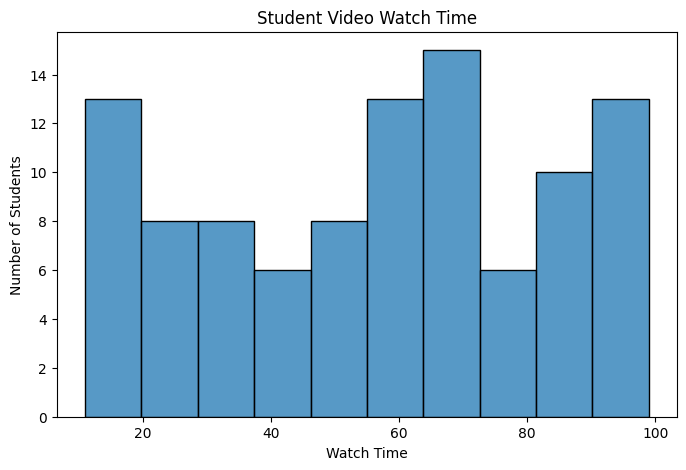

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Watch_Time"], bins=10)
plt.title("Student Video Watch Time")
plt.xlabel("Watch Time")
plt.ylabel("Number of Students")
plt.show()

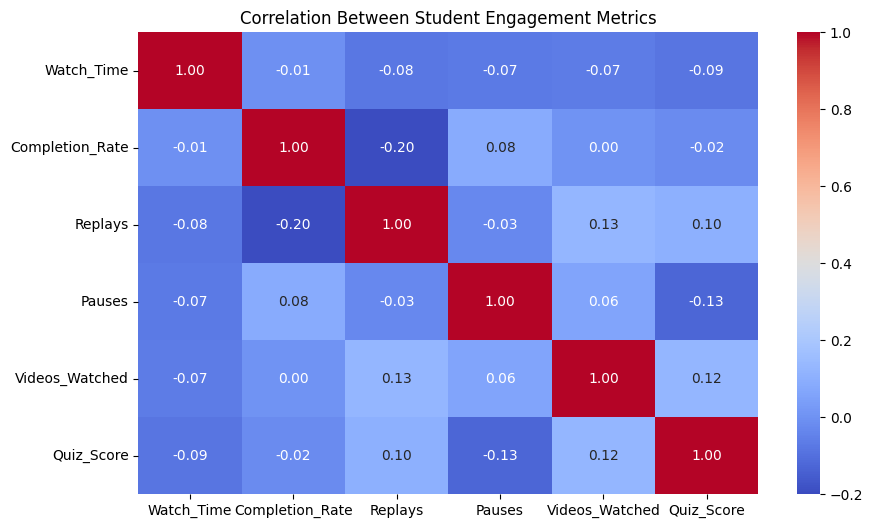

In [5]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.drop(columns=["Student_ID"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Student Engagement Metrics")
plt.show()

In [6]:
features = [
    "Watch_Time",
    "Completion_Rate",
    "Replays",
    "Pauses",
    "Videos_Watched",
    "Quiz_Score"
]

X = df[features]

X.head()

,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
0,61,90,1,7,9,39
1,24,28,7,3,10,98
2,81,20,5,2,14,63
3,70,27,7,8,13,81
4,30,82,6,2,6,39


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.15914678,  1.40778846, -1.05259089,  1.04416371,  0.26193688,
        -1.17694805],
       [-1.20391592, -1.17760504,  1.35792259, -0.34342926,  0.50904714,
         1.86199877],
       [ 0.89593743, -1.5112042 ,  0.5544181 , -0.69032751,  1.49748819,
         0.05923371],
       [ 0.49070257, -1.21930493,  1.35792259,  1.39106196,  1.25037793,
         0.98637003],
       [-0.98287873,  1.0741893 ,  0.95617035, -0.69032751, -0.47939391,
        -1.17694805]])

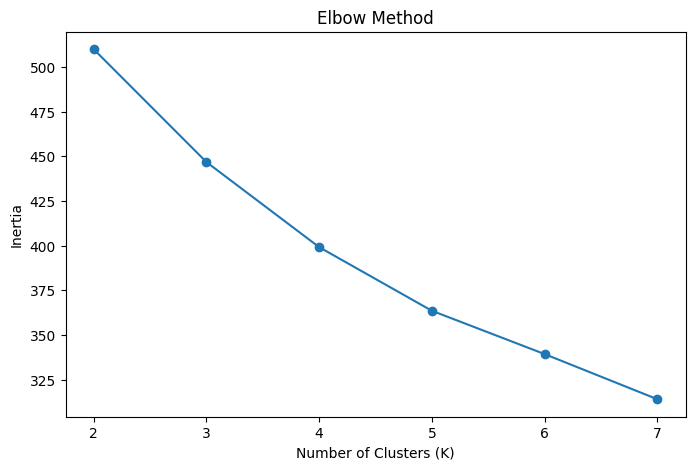

In [8]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 8), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Cluster
0,S001,61,90,1,7,9,39,1
1,S002,24,28,7,3,10,98,0
2,S003,81,20,5,2,14,63,0
3,S004,70,27,7,8,13,81,0
4,S005,30,82,6,2,6,39,1


In [10]:
cluster_summary = df.groupby("Cluster")[features].mean()

cluster_summary

,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
Cluster,,,,,,
0,48.838710,43.741935,6.258065,3.806452,9.806452,71.161290
1,68.500000,57.421053,3.131579,4.315789,5.289474,45.763158
2,50.032258,67.290323,1.580645,3.774194,9.322581,72.258065


In [11]:
cluster_names = {
    0: "Low Engagement",
    1: "High Engagement",
    2: "Medium Engagement"
}

df["Engagement_Level"] = df["Cluster"].map(cluster_names)

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Cluster,Engagement_Level
0,S001,61,90,1,7,9,39,1,High Engagement
1,S002,24,28,7,3,10,98,0,Low Engagement
2,S003,81,20,5,2,14,63,0,Low Engagement
3,S004,70,27,7,8,13,81,0,Low Engagement
4,S005,30,82,6,2,6,39,1,High Engagement


In [12]:
df["Engagement_Level"].value_counts()

,count
Engagement_Level,
High Engagement,38
Low Engagement,31
Medium Engagement,31


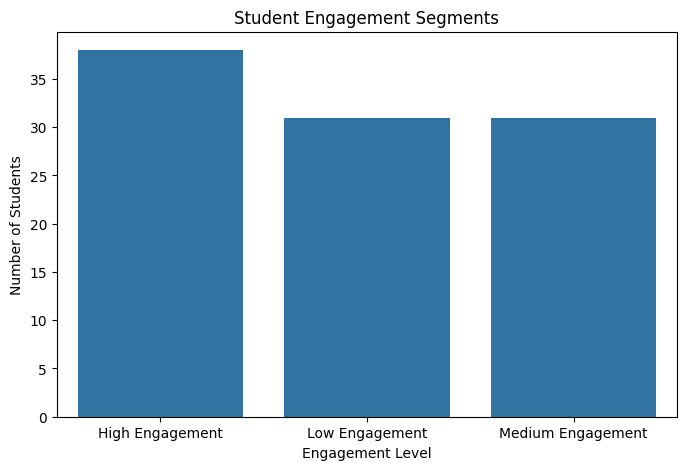

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Engagement_Level"
)

plt.title("Student Engagement Segments")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Students")
plt.show()

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(100, 2)

In [15]:
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Cluster,Engagement_Level,PCA1,PCA2
0,S001,61,90,1,7,9,39,1,High Engagement,-1.866844,1.334078
1,S002,24,28,7,3,10,98,0,Low Engagement,2.753379,0.034253
2,S003,81,20,5,2,14,63,0,Low Engagement,1.425163,-0.891619
3,S004,70,27,7,8,13,81,0,Low Engagement,1.852518,0.599776
4,S005,30,82,6,2,6,39,1,High Engagement,-0.205207,0.234124


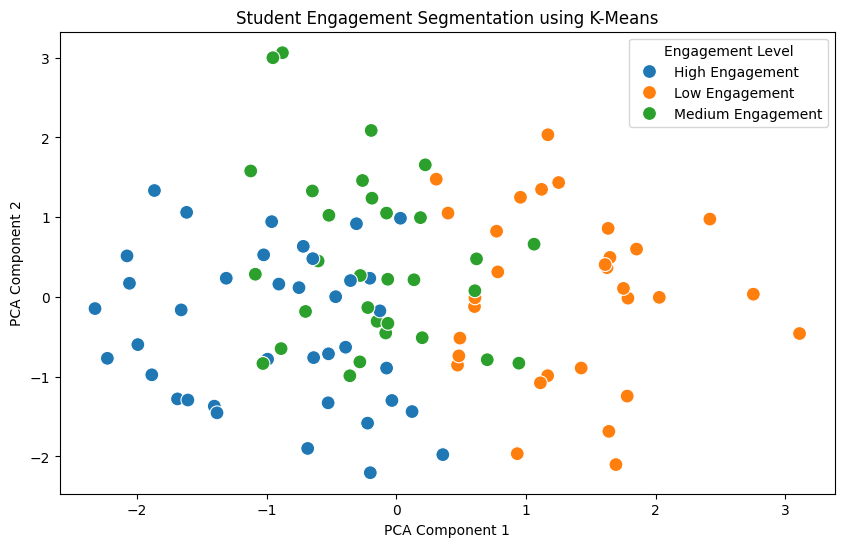

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Engagement_Level",
    s=100
)

plt.title("Student Engagement Segmentation using K-Means")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Engagement Level")
plt.show()

In [17]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.137


In [18]:
final_df = df[
    [
        "Student_ID",
        "Watch_Time",
        "Completion_Rate",
        "Replays",
        "Pauses",
        "Videos_Watched",
        "Quiz_Score",
        "Engagement_Level"
    ]
]

final_df.head(10)

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Engagement_Level
0,S001,61,90,1,7,9,39,High Engagement
1,S002,24,28,7,3,10,98,Low Engagement
2,S003,81,20,5,2,14,63,Low Engagement
3,S004,70,27,7,8,13,81,Low Engagement
4,S005,30,82,6,2,6,39,High Engagement
5,S006,92,30,3,8,10,48,High Engagement
6,S007,96,27,6,1,10,87,Low Engagement
7,S008,84,54,2,1,6,30,High Engagement
8,S009,84,54,7,1,1,98,Low Engagement
9,S010,97,52,2,5,4,33,High Engagement


In [19]:
final_df["Engagement_Level"].value_counts()

,count
Engagement_Level,
High Engagement,38
Low Engagement,31
Medium Engagement,31


In [20]:
lecture_text = """
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task.

There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning.

Supervised learning uses labelled data to train a model. The model learns
the relationship between input features and known output labels.
Classification and regression are common supervised learning tasks.

Classification is used when the output is a category. For example,
predicting whether an email is spam or not spam is a classification problem.

Regression is used when the output is a continuous numerical value.
Predicting house prices based on features such as area, location, and
number of rooms is an example of regression.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.

K-Means is a popular clustering algorithm. It divides data points into
K groups called clusters. Each cluster is represented by a centroid.
The algorithm assigns data points to the nearest centroid and repeatedly
updates the centroids until the clusters become stable.

Classification and regression are different because classification
predicts discrete categories, while regression predicts continuous values.

Machine learning models are usually evaluated using suitable performance
metrics. Accuracy, precision, recall, and F1-score are commonly used for
classification problems.
"""

print(lecture_text)


Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task.

There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning.

Supervised learning uses labelled data to train a model. The model learns
the relationship between input features and known output labels.
Classification and regression are common supervised learning tasks.

Classification is used when the output is a category. For example,
predicting whether an email is spam or not spam is a classification problem.

Regression is used when the output is a continuous numerical value.
Predicting house prices based on features such as area, location, and
number of rooms is an example of regression.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervis

In [21]:
import re

sentences = re.split(r'(?<=[.!?])\s+', lecture_text.strip())

chunks = []

chunk_size = 3

for i in range(0, len(sentences), chunk_size):
    chunk = " ".join(sentences[i:i + chunk_size])
    chunks.append(chunk)

print("Number of chunks:", len(chunks))

for i, chunk in enumerate(chunks):
    print(f"\nChunk {i}:")
    print(chunk)

Number of chunks: 7

Chunk 0:
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task. There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning. Supervised learning uses labelled data to train a model.

Chunk 1:
The model learns
the relationship between input features and known output labels. Classification and regression are common supervised learning tasks. Classification is used when the output is a category.

Chunk 2:
For example,
predicting whether an email is spam or not spam is a classification problem. Regression is used when the output is a continuous numerical value. Predicting house prices based on features such as area, location, and
number of rooms is an example of regression.

Chunk 3:
Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or

In [22]:
!pip install -q sentence-transformers

In [23]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(chunks)

print("Embedding shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (7, 384)


In [24]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 74.8 MB/s eta 0:00:00


In [25]:
import faiss
import numpy as np

In [26]:
embeddings = np.array(embeddings).astype("float32")

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("Number of vectors:", index.ntotal)

Number of vectors: 7


In [27]:
def search_lecture(question, top_k=3):

    # Convert question into embedding
    question_embedding = embedding_model.encode([question])
    question_embedding = np.array(question_embedding).astype("float32")

    # Search similar chunks
    distances, indices = index.search(question_embedding, top_k)

    results = []

    for i in indices[0]:
        results.append(chunks[i])

    return results

In [28]:
question = "What is K-Means clustering?"

results = search_lecture(question)

for i, result in enumerate(results):
    print(f"\nResult {i+1}:")
    print(result)


Result 1:
K-Means is a popular clustering algorithm. It divides data points into
K groups called clusters. Each cluster is represented by a centroid.

Result 2:
Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.

Result 3:
The algorithm assigns data points to the nearest centroid and repeatedly
updates the centroids until the clusters become stable. Classification and regression are different because classification
predicts discrete categories, while regression predicts continuous values. Machine learning models are usually evaluated using suitable performance
metrics.


In [29]:
question = "What is supervised learning?"

results = search_lecture(question)

for i, result in enumerate(results):
    print(f"\nResult {i+1}:")
    print(result)


Result 1:
The model learns
the relationship between input features and known output labels. Classification and regression are common supervised learning tasks. Classification is used when the output is a category.

Result 2:
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task. There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning. Supervised learning uses labelled data to train a model.

Result 3:
Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.


In [30]:
def get_context(question, top_k=3):

    results = search_lecture(question, top_k)

    context = "\n\n".join(results)

    return context

In [31]:
question = "What is K-Means clustering?"

context = get_context(question)

print(context)

K-Means is a popular clustering algorithm. It divides data points into
K groups called clusters. Each cluster is represented by a centroid.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.

The algorithm assigns data points to the nearest centroid and repeatedly
updates the centroids until the clusters become stable. Classification and regression are different because classification
predicts discrete categories, while regression predicts continuous values. Machine learning models are usually evaluated using suitable performance
metrics.


In [32]:
!pip install -q huggingface_hub

In [33]:
from huggingface_hub import InferenceClient

In [34]:
from google.colab import userdata

HF_TOKEN = userdata.get("pblm1")

print("Token loaded:", HF_TOKEN is not None)

Token loaded: True


In [35]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=HF_TOKEN
)

print("LLM client connected successfully!")

LLM client connected successfully!


In [36]:
def generate_answer(question):

    context = get_context(question, top_k=3)

    prompt = f"""
You are an AI course guide for students.

Use ONLY the lecture content below to answer the question.

Lecture Content:
{context}

Student Question:
{question}

If the answer is not present in the lecture,
say "I could not find this information in the lecture."

Answer in simple English.
"""

    response = client.chat_completion(
        model="openai/gpt-oss-120b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=200
    )

    return response.choices[0].message.content

In [37]:
response = client.chat_completion(
    model="openai/gpt-oss-120b",
    messages=[
        {
            "role": "user",
            "content": "What is machine learning? Explain in simple English."
        }
    ],
    max_tokens=100
)

print(response.choices[0].message.content)

**Machine learning (ML) is a way for computers to get better at a task by learning from data, instead of being told step‑by‑step exactly what to do.


In [38]:
question = "What is K-Means clustering?"

answer = generate_answer(question)

print("Student:", question)
print("\nAI Course Guide:")
print(answer)

Student: What is K-Means clustering?

AI Course Guide:
K-Means clustering is a method that groups data points into a set number of clusters (called **K**). Each cluster has a “center” called a **centroid**. The algorithm works by repeatedly:

1. Assigning each data point to the nearest centroid.
2. Updating the centroids based on the points assigned to them.

These steps keep repeating until the groups stop changing, meaning the clusters are stable. It’s a common way to find hidden patterns in unlabeled (unsupervised) data.


In [39]:
!pip install -q gradio

In [40]:
import gradio as gr

def course_guide(question):
    if not question.strip():
        return "Please enter a question."

    return generate_answer(question)

demo = gr.Interface(
    fn=course_guide,
    inputs=gr.Textbox(
        label="Ask your ML Lecture Question",
        placeholder="Example: What is K-Means clustering?"
    ),
    outputs=gr.Textbox(
        label="AI Course Guide"
    ),
    title="🎓 AI Course Guide",
    description="Ask questions based on the Machine Learning lecture."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://361f87c3a4ecc96342.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [41]:
# Install all dependencies used in this notebook (safe to re-run)
!pip install -q sentence-transformers faiss-cpu huggingface_hub gradio scikit-learn pandas numpy matplotlib seaborn


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

np.random.seed(42)

FEATURES = [
    "Watch_Time",
    "Completion_Rate",
    "Replays",
    "Pauses",
    "Videos_Watched",
    "Quiz_Score",
]

def load_engagement_data(n_students: int = 100) -> pd.DataFrame:
    """Load engagement metrics.

    Replace this with `pd.read_csv('your_file.csv')` to use a real
    export from your LMS instead of the synthetic demo data.
    """
    data = {
        "Student_ID": [f"S{i:03d}" for i in range(1, n_students + 1)],
        "Watch_Time": np.random.randint(10, 100, n_students),
        "Completion_Rate": np.random.randint(20, 100, n_students),
        "Replays": np.random.randint(0, 8, n_students),
        "Pauses": np.random.randint(0, 10, n_students),
        "Videos_Watched": np.random.randint(1, 15, n_students),
        "Quiz_Score": np.random.randint(30, 100, n_students),
    }
    return pd.DataFrame(data)

df = load_engagement_data()
df.head()


,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
0,S001,61,90,1,7,9,39
1,S002,24,28,7,3,10,98
2,S003,81,20,5,2,14,63
3,S004,70,27,7,8,13,81
4,S005,30,82,6,2,6,39


In [43]:
def segment_students(df: pd.DataFrame, k: int = 3):
    """Scale features, run KMeans, and attach human-readable
    Engagement_Level labels ranked by average Quiz_Score (so the
    labels are always correct even if cluster IDs shuffle between runs).
    """
    X = df[FEATURES]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df = df.copy()
    df["Cluster"] = kmeans.fit_predict(X_scaled)

    # Rank clusters by mean Quiz_Score so labels are meaningful regardless
    # of which integer KMeans happened to assign to which group.
    ranking = df.groupby("Cluster")["Quiz_Score"].mean().sort_values().index.tolist()
    level_names = ["Low Engagement", "Medium Engagement", "High Engagement"]
    # if k != 3, fall back to generic numbered labels
    if k == 3:
        cluster_to_label = {cluster_id: level_names[i] for i, cluster_id in enumerate(ranking)}
    else:
        cluster_to_label = {cluster_id: f"Level {i+1}" for i, cluster_id in enumerate(ranking)}

    df["Engagement_Level"] = df["Cluster"].map(cluster_to_label)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)
    df["PCA1"], df["PCA2"] = coords[:, 0], coords[:, 1]

    score = silhouette_score(X_scaled, df["Cluster"])
    return df, kmeans, scaler, score


segmented_df, kmeans_model, scaler_model, sil_score = segment_students(df, k=3)
print("Silhouette score:", round(sil_score, 3))
segmented_df[["Student_ID", *FEATURES, "Engagement_Level"]].head(10)


Silhouette score: 0.137


,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Engagement_Level
0,S001,61,90,1,7,9,39,Low Engagement
1,S002,24,28,7,3,10,98,Medium Engagement
2,S003,81,20,5,2,14,63,Medium Engagement
3,S004,70,27,7,8,13,81,Medium Engagement
4,S005,30,82,6,2,6,39,Low Engagement
5,S006,92,30,3,8,10,48,Low Engagement
6,S007,96,27,6,1,10,87,Medium Engagement
7,S008,84,54,2,1,6,30,Low Engagement
8,S009,84,54,7,1,1,98,Medium Engagement
9,S010,97,52,2,5,4,33,Low Engagement


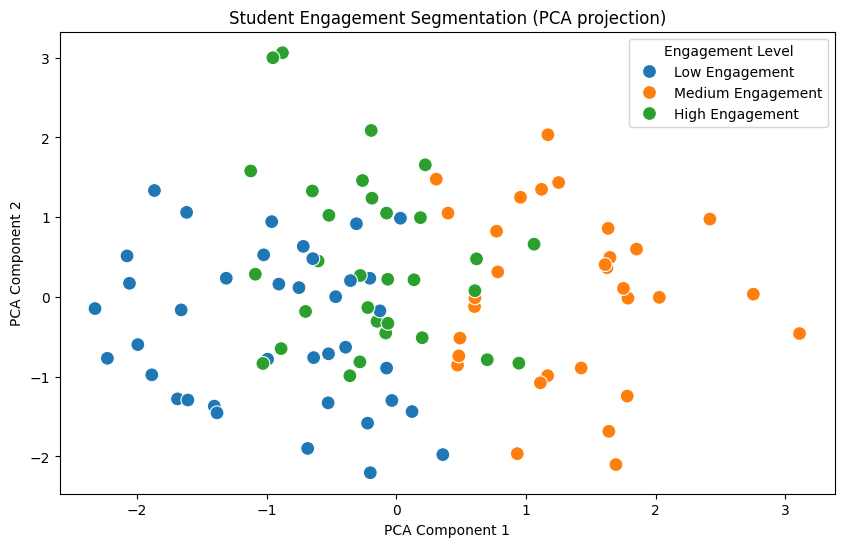

,count
Engagement_Level,
Low Engagement,38
Medium Engagement,31
High Engagement,31


In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=segmented_df,
    x="PCA1", y="PCA2",
    hue="Engagement_Level",
    s=100,
)
plt.title("Student Engagement Segmentation (PCA projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Engagement Level")
plt.show()

segmented_df["Engagement_Level"].value_counts()


In [45]:
# Persist the segmentation result — this is what you commit to the repo
output_cols = ["Student_ID", *FEATURES, "Engagement_Level"]
segmented_df[output_cols].to_csv("segmented_students.csv", index=False)
print("Saved segmented_students.csv")
segmented_df[output_cols].head()


Saved segmented_students.csv


,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Engagement_Level
0,S001,61,90,1,7,9,39,Low Engagement
1,S002,24,28,7,3,10,98,Medium Engagement
2,S003,81,20,5,2,14,63,Medium Engagement
3,S004,70,27,7,8,13,81,Medium Engagement
4,S005,30,82,6,2,6,39,Low Engagement


In [46]:
from google.colab import files

def load_transcript() -> str:
    print("Upload a lecture transcript (.txt). Press Cancel/skip to use the built-in demo transcript.")
    try:
        uploaded = files.upload()
    except Exception:
        uploaded = {}

    if uploaded:
        filename = next(iter(uploaded))
        return uploaded[filename].decode("utf-8")

    # Fallback demo transcript
    return """
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task.

There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning.

Supervised learning uses labelled data to train a model. The model learns
the relationship between input features and known output labels.
Classification and regression are common supervised learning tasks.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering, such as K-Means, is a
common unsupervised learning technique that groups similar data points
together based on distance between them.

Reinforcement learning trains an agent to make decisions by rewarding
good actions and penalising bad ones, so the agent learns an optimal
strategy through trial and error.
"""

lecture_text = load_transcript()
print("Transcript length (chars):", len(lecture_text))


Upload a lecture transcript (.txt). Press Cancel/skip to use the built-in demo transcript.


Transcript length (chars): 958


In [47]:
import re

def chunk_text(text: str, chunk_size: int = 3, overlap: int = 1) -> list[str]:
    """Split transcript into overlapping sentence-group chunks so that
    context is not lost at chunk boundaries.
    """
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s]

    chunks = []
    step = max(chunk_size - overlap, 1)
    for i in range(0, len(sentences), step):
        chunk = " ".join(sentences[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    return chunks

chunks = chunk_text(lecture_text)
print("Number of chunks:", len(chunks))
print("\nExample chunk:\n", chunks[0])


Number of chunks: 5

Example chunk:
 Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task. There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning. Supervised learning uses labelled data to train a model.


In [48]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

class CourseGuideIndex:
    """Wraps embedding + FAISS retrieval for a set of transcript chunks."""

    def __init__(self, chunks: list[str], model_name: str = "all-MiniLM-L6-v2"):
        self.chunks = chunks
        self.model = SentenceTransformer(model_name)
        embeddings = self.model.encode(chunks)
        self.embeddings = np.array(embeddings).astype("float32")

        self.index = faiss.IndexFlatL2(self.embeddings.shape[1])
        self.index.add(self.embeddings)

    def retrieve(self, question: str, top_k: int = 3) -> list[str]:
        q_emb = self.model.encode([question])
        q_emb = np.array(q_emb).astype("float32")
        _, indices = self.index.search(q_emb, top_k)
        return [self.chunks[i] for i in indices[0]]

    def get_context(self, question: str, top_k: int = 3) -> str:
        return "\n\n".join(self.retrieve(question, top_k))


course_index = CourseGuideIndex(chunks)
print("Indexed vectors:", course_index.index.ntotal)
print("\nTest retrieval for 'What is K-Means clustering?':\n")
for r in course_index.retrieve("What is K-Means clustering?"):
    print("-", r, "\n")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Indexed vectors: 5

Test retrieval for 'What is K-Means clustering?':

- The objective is to find
hidden patterns or groups in the data. Clustering, such as K-Means, is a
common unsupervised learning technique that groups similar data points
together based on distance between them. Reinforcement learning trains an agent to make decisions by rewarding
good actions and penalising bad ones, so the agent learns an optimal
strategy through trial and error. 

- Classification and regression are common supervised learning tasks. Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. 

- Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task. There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning. Supervised learning uses labelled data to

In [49]:
# LLM setup (Hugging Face Inference API)
# Add your HF token as a Colab secret named "pblm1" (Runtime > Secrets),
# same as in the Day 1 notebook.
from google.colab import userdata
from huggingface_hub import InferenceClient

HF_TOKEN = userdata.get("pblm1")
print("Token loaded:", HF_TOKEN is not None)

llm_client = InferenceClient(provider="auto", api_key=HF_TOKEN)
LLM_MODEL = "openai/gpt-oss-120b"


Token loaded: True


In [50]:
def generate_answer(question: str, index: "CourseGuideIndex", top_k: int = 3) -> str:
    """Full RAG step: retrieve context, build a grounded prompt, call the LLM."""
    context = index.get_context(question, top_k=top_k)

    prompt = f"""You are an AI course guide for students.

Use ONLY the lecture content below to answer the question.

Lecture Content:
{context}

Student Question:
{question}

If the answer is not present in the lecture, say
"I could not find this information in the lecture."

Answer in simple English.
"""

    response = llm_client.chat_completion(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200,
    )
    return response.choices[0].message.content


# Quick test
test_question = "What is K-Means clustering?"
print("Student:", test_question)
print("\nAI Course Guide:", generate_answer(test_question, course_index))


Student: What is K-Means clustering?

AI Course Guide: K‑Means clustering is an unsupervised learning method that groups data points that are similar to each other. It does this by looking at the distances between points and putting together those that are close, forming distinct clusters.


In [51]:
import gradio as gr

def lookup_segment(student_id: str):
    student_id = student_id.strip().upper()
    row = segmented_df[segmented_df["Student_ID"] == student_id]
    if row.empty:
        return f"No student found with ID '{student_id}'. Try one of: " + ", ".join(segmented_df['Student_ID'].head(5))
    row = row.iloc[0]
    return (
        f"Student: {row['Student_ID']}\n"
        f"Engagement Level: {row['Engagement_Level']}\n\n"
        f"Watch Time: {row['Watch_Time']}\n"
        f"Completion Rate: {row['Completion_Rate']}%\n"
        f"Replays: {row['Replays']}\n"
        f"Pauses: {row['Pauses']}\n"
        f"Videos Watched: {row['Videos_Watched']}\n"
        f"Quiz Score: {row['Quiz_Score']}"
    )


def ask_course_guide(question: str):
    if not question.strip():
        return "Please enter a question."
    return generate_answer(question, course_index)


with gr.Blocks(title="Student Segmentation & AI Course Guide") as demo:
    gr.Markdown("# 🎓 Student Segmentation & AI Course Guide")

    with gr.Tab("Segment Lookup"):
        sid_input = gr.Textbox(label="Student ID", placeholder="e.g. S001")
        sid_output = gr.Textbox(label="Result", lines=8)
        gr.Button("Look up").click(lookup_segment, inputs=sid_input, outputs=sid_output)

    with gr.Tab("Ask the Course Guide"):
        q_input = gr.Textbox(label="Ask your lecture question", placeholder="e.g. What is supervised learning?")
        q_output = gr.Textbox(label="AI Course Guide", lines=6)
        gr.Button("Ask").click(ask_course_guide, inputs=q_input, outputs=q_output)

demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://be64852eab466f5609.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [52]:
!pip install -q sentence-transformers faiss-cpu huggingface_hub gradio scikit-learn pandas numpy

In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(42)

FEATURES = ["Watch_Time", "Completion_Rate", "Replays", "Pauses", "Videos_Watched", "Quiz_Score"]

def load_engagement_data(n_students: int = 100) -> pd.DataFrame:
    data = {
        "Student_ID": [f"S{i:03d}" for i in range(1, n_students + 1)],
        "Watch_Time": np.random.randint(10, 100, n_students),
        "Completion_Rate": np.random.randint(20, 100, n_students),
        "Replays": np.random.randint(0, 8, n_students),
        "Pauses": np.random.randint(0, 10, n_students),
        "Videos_Watched": np.random.randint(1, 15, n_students),
        "Quiz_Score": np.random.randint(30, 100, n_students),
    }
    return pd.DataFrame(data)

def segment_students(df: pd.DataFrame, k: int = 3):
    X_scaled = StandardScaler().fit_transform(df[FEATURES])
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df = df.copy()
    df["Cluster"] = kmeans.fit_predict(X_scaled)
    ranking = df.groupby("Cluster")["Quiz_Score"].mean().sort_values().index.tolist()
    level_names = ["Low Engagement", "Medium Engagement", "High Engagement"]
    cluster_to_label = {c: level_names[i] for i, c in enumerate(ranking)}
    df["Engagement_Level"] = df["Cluster"].map(cluster_to_label)
    return df

df = load_engagement_data()
segmented_df = segment_students(df)
segmented_df[["Student_ID", "Engagement_Level"]].head()


,Student_ID,Engagement_Level
0,S001,Low Engagement
1,S002,Medium Engagement
2,S003,Medium Engagement
3,S004,Medium Engagement
4,S005,Low Engagement


In [54]:
def get_student_segment(student_id: str) -> str | None:
    """Look up a student's engagement level. Returns None if not found."""
    student_id = student_id.strip().upper()
    row = segmented_df[segmented_df["Student_ID"] == student_id]
    if row.empty:
        return None
    return row.iloc[0]["Engagement_Level"]

print(get_student_segment("S001"))


Low Engagement


In [55]:
from google.colab import files

def load_transcript() -> str:
    print("Upload a lecture transcript (.txt). Skip to use the built-in demo transcript.")
    try:
        uploaded = files.upload()
    except Exception:
        uploaded = {}
    if uploaded:
        filename = next(iter(uploaded))
        return uploaded[filename].decode("utf-8")
    return """
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task.

There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning.

Supervised learning uses labelled data to train a model. The model learns
the relationship between input features and known output labels.
Classification and regression are common supervised learning tasks.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering, such as K-Means, is a
common unsupervised learning technique that groups similar data points
together based on distance between them.

Reinforcement learning trains an agent to make decisions by rewarding
good actions and penalising bad ones, so the agent learns an optimal
strategy through trial and error.
"""

lecture_text = load_transcript()
print("Transcript length (chars):", len(lecture_text))


Upload a lecture transcript (.txt). Skip to use the built-in demo transcript.


Transcript length (chars): 958


In [56]:
import re

def chunk_text(text: str, chunk_size: int = 3, overlap: int = 1) -> list[str]:
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s]
    chunks = []
    step = max(chunk_size - overlap, 1)
    for i in range(0, len(sentences), step):
        chunk = " ".join(sentences[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    return chunks

chunks = chunk_text(lecture_text)
print("Number of chunks:", len(chunks))


Number of chunks: 5


In [57]:
from sentence_transformers import SentenceTransformer
import faiss

class CourseGuideIndex:
    def __init__(self, chunks: list[str], model_name: str = "all-MiniLM-L6-v2"):
        self.chunks = chunks
        self.model = SentenceTransformer(model_name)
        emb = np.array(self.model.encode(chunks)).astype("float32")
        self.index = faiss.IndexFlatL2(emb.shape[1])
        self.index.add(emb)

    def retrieve(self, question: str, top_k: int = 3) -> list[str]:
        q_emb = np.array(self.model.encode([question])).astype("float32")
        _, idx = self.index.search(q_emb, top_k)
        return [self.chunks[i] for i in idx[0]]

    def get_context(self, question: str, top_k: int = 3) -> str:
        return "\n\n".join(self.retrieve(question, top_k))

course_index = CourseGuideIndex(chunks)
print("Indexed vectors:", course_index.index.ntotal)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Indexed vectors: 5


In [58]:
from google.colab import userdata
from huggingface_hub import InferenceClient

HF_TOKEN = userdata.get("pblm1")
llm_client = InferenceClient(provider="auto", api_key=HF_TOKEN)
LLM_MODEL = "openai/gpt-oss-120b"
print("Token loaded:", HF_TOKEN is not None)


Token loaded: True


In [59]:
SEGMENT_STYLE = {
    "Low Engagement": (
        "The student has LOW engagement so far. Use very simple language, short sentences, "
        "give a concrete everyday example, and end with one encouraging sentence motivating "
        "them to keep watching the lectures."
    ),
    "Medium Engagement": (
        "The student has MEDIUM engagement. Give a clear, moderately detailed answer, and end "
        "with one practical tip for applying the concept."
    ),
    "High Engagement": (
        "The student has HIGH engagement. Give a more detailed, technical answer, and end by "
        "pointing them to a more advanced related concept worth exploring next."
    ),
}

# A tiny topic map used for the rule-based "what to study next" recommendation.
# Extend this with your real course's module list.
COURSE_TOPICS = {
    "Supervised Learning": ["supervised", "classification", "regression", "labelled"],
    "Unsupervised Learning": ["unsupervised", "clustering", "k-means", "unlabeled"],
    "Reinforcement Learning": ["reinforcement", "reward", "agent", "trial and error"],
}

def recommend_topic(question: str, engagement_level: str) -> str:
    """Rule-based recommendation: match the question to a known topic, then suggest a
    next step calibrated to the student's engagement level.
    """
    q_lower = question.lower()
    matched_topic = None
    for topic, keywords in COURSE_TOPICS.items():
        if any(kw in q_lower for kw in keywords):
            matched_topic = topic
            break
    matched_topic = matched_topic or "the core lecture material"

    if engagement_level == "Low Engagement":
        return f"Next step: rewatch the short intro section on '{matched_topic}' before moving on."
    elif engagement_level == "Medium Engagement":
        return f"Next step: try a practice question on '{matched_topic}' to check your understanding."
    else:
        return f"Next step: explore an advanced resource on '{matched_topic}' beyond the lecture."


In [60]:
def generate_personalized_answer(student_id: str, question: str, top_k: int = 3) -> dict:
    """Full Day 3 pipeline: segment lookup -> retrieval -> personalized prompt -> LLM ->
    answer + recommendation. Returns a dict so the Gradio app can display each part.
    """
    segment = get_student_segment(student_id)
    if segment is None:
        return {
            "segment": None,
            "answer": f"No student found with ID '{student_id}'.",
            "recommendation": "",
        }

    context = course_index.get_context(question, top_k=top_k)
    style_instruction = SEGMENT_STYLE[segment]

    prompt = f"""You are an AI course guide for students.

Use ONLY the lecture content below to answer the question.

Lecture Content:
{context}

Student Question:
{question}

Personalization instruction: {style_instruction}

If the answer is not present in the lecture, say
"I could not find this information in the lecture."
"""

    response = llm_client.chat_completion(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=220,
    )
    answer = response.choices[0].message.content
    recommendation = recommend_topic(question, segment)

    return {"segment": segment, "answer": answer, "recommendation": recommendation}


# Quick test — try the same question for a couple of different students to see the
# tailored tone/depth change with their engagement level.
for sid in ["S001", "S002"]:
    result = generate_personalized_answer(sid, "What is K-Means clustering?")
    print(f"--- {sid} ({result['segment']}) ---")
    print(result["answer"])
    print(result["recommendation"])
    print()


--- S001 (Low Engagement) ---
K‑Means clustering is an unsupervised learning method.  
It groups data points that are close to each other. The algorithm looks at the distance between points and puts similar ones into the same cluster.

**Everyday example:** Imagine you have a mixed bowl of apples and oranges. By looking at size and color, you separate them into two piles—one for apples and one for oranges. K‑Means does the same thing with data, but using mathematical distance instead of visual cues.

Keep watching the lectures—you’re doing great!
Next step: rewatch the short intro section on 'Unsupervised Learning' before moving on.

--- S002 (Medium Engagement) ---
K‑Means is a **clustering** method that belongs to the unsupervised‑learning family.  
In K‑Means the algorithm looks for **hidden groups** (clusters) in a set of unlabeled data points. It does this by repeatedly assigning each point to the cluster whose centre (the “mean” of the points in that cluster) is closest, measurin

In [61]:
import gradio as gr

def run_pipeline(student_id: str, question: str):
    if not student_id.strip():
        return "Enter a Student ID.", "", ""
    if not question.strip():
        return "Enter a question.", "", ""

    result = generate_personalized_answer(student_id, question)
    segment_text = result["segment"] or "Student not found"
    return segment_text, result["answer"], result["recommendation"]


with gr.Blocks(title="Personalized Course Guide") as demo:
    gr.Markdown("# 🎓 Personalized Course Guide (Day 3)")
    gr.Markdown("Answers and study recommendations adapt to the student's engagement segment.")

    sid_input = gr.Textbox(label="Student ID", placeholder="e.g. S001")
    q_input = gr.Textbox(label="Question", placeholder="e.g. What is K-Means clustering?")
    run_btn = gr.Button("Ask")

    segment_output = gr.Textbox(label="Engagement Segment")
    answer_output = gr.Textbox(label="Personalized Answer", lines=6)
    rec_output = gr.Textbox(label="Recommended Next Step")

    run_btn.click(run_pipeline, inputs=[sid_input, q_input],
                   outputs=[segment_output, answer_output, rec_output])

demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://af416912e8d5818452.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [62]:
!pip install -q sentence-transformers faiss-cpu pandas numpy


In [63]:
COURSE_MODULES = [
    {
        "module_id": "M1",
        "title": "Supervised Learning",
        "difficulty": "Beginner",
        "prerequisites": [],
        "estimated_minutes": 25,
        "transcript": """
Supervised learning uses labelled data to train a model. The model learns
the relationship between input features and known output labels.

Classification and regression are the two main supervised learning tasks.
Classification predicts a category, such as whether an email is spam or not.
Regression predicts a continuous number, such as the price of a house.

Common supervised learning algorithms include linear regression, logistic
regression, decision trees, and support vector machines. The model is
trained by minimising the difference between its predictions and the true
labels in the training data.
""",
    },
    {
        "module_id": "M2",
        "title": "Unsupervised Learning",
        "difficulty": "Intermediate",
        "prerequisites": ["M1"],
        "estimated_minutes": 30,
        "transcript": """
Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data without being told the correct
answer in advance.

Clustering is the most common unsupervised learning technique. K-Means is
a popular clustering algorithm that groups similar data points together
based on distance, by repeatedly assigning points to the nearest cluster
centre and then recomputing the centres.

Dimensionality reduction, such as PCA, is another unsupervised technique.
It compresses many features into fewer components while keeping as much
information as possible, which is useful for visualisation.
""",
    },
    {
        "module_id": "M3",
        "title": "Reinforcement Learning",
        "difficulty": "Advanced",
        "prerequisites": ["M1", "M2"],
        "estimated_minutes": 35,
        "transcript": """
Reinforcement learning trains an agent to make decisions by interacting
with an environment. The agent receives a reward or penalty after each
action, and learns an optimal strategy, called a policy, through trial
and error.

Unlike supervised learning, there are no labelled examples. Instead the
agent must explore different actions to discover which ones lead to the
highest long-term reward, balancing exploration of new actions against
exploitation of actions already known to work well.

Reinforcement learning is used in robotics, game playing, and recommendation
systems, where an agent repeatedly interacts with an environment over time.
""",
    },
]

print("Modules defined:", [m["title"] for m in COURSE_MODULES])


Modules defined: ['Supervised Learning', 'Unsupervised Learning', 'Reinforcement Learning']


In [64]:
import re

def chunk_text(text: str, chunk_size: int = 3, overlap: int = 1) -> list[str]:
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s]
    chunks = []
    step = max(chunk_size - overlap, 1)
    for i in range(0, len(sentences), step):
        chunk = " ".join(sentences[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    return chunks


def build_tagged_chunks(modules):
    """Returns a flat list of {text, module_id, title, difficulty} dicts —
    one per chunk, each remembering which module it came from.
    """
    tagged = []
    for module in modules:
        for chunk in chunk_text(module["transcript"]):
            tagged.append({
                "text": chunk,
                "module_id": module["module_id"],
                "title": module["title"],
                "difficulty": module["difficulty"],
            })
    return tagged

tagged_chunks = build_tagged_chunks(COURSE_MODULES)
print("Total chunks across all modules:", len(tagged_chunks))
tagged_chunks[0]


Total chunks across all modules: 10


{'text': 'Supervised learning uses labelled data to train a model. The model learns\nthe relationship between input features and known output labels. Classification and regression are the two main supervised learning tasks.',
 'module_id': 'M1',
 'title': 'Supervised Learning',
 'difficulty': 'Beginner'}

In [65]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd

class CourseKnowledgeBase:
    """A metadata-aware knowledge base: embeds every chunk, indexes it with FAISS,
    and can filter retrieval down to a single module.
    """

    def __init__(self, tagged_chunks: list[dict], modules: list[dict], model_name: str = "all-MiniLM-L6-v2"):
        self.chunks = tagged_chunks
        self.modules_by_id = {m["module_id"]: m for m in modules}
        self.model = SentenceTransformer(model_name)

        texts = [c["text"] for c in tagged_chunks]
        embeddings = np.array(self.model.encode(texts)).astype("float32")
        self.index = faiss.IndexFlatL2(embeddings.shape[1])
        self.index.add(embeddings)

    def search(self, question: str, top_k: int = 3, module_id: str | None = None) -> list[dict]:
        """Search the whole knowledge base, or restrict to one module_id."""
        q_emb = np.array(self.model.encode([question])).astype("float32")
        # over-fetch then filter, so module filtering still returns top_k relevant results
        fetch_k = top_k * 5 if module_id else top_k
        _, indices = self.index.search(q_emb, min(fetch_k, len(self.chunks)))

        results = [self.chunks[i] for i in indices[0]]
        if module_id:
            results = [r for r in results if r["module_id"] == module_id]
        return results[:top_k]

    def get_context(self, question: str, top_k: int = 3, module_id: str | None = None) -> str:
        results = self.search(question, top_k, module_id)
        return "\n\n".join(f"[{r['title']}] {r['text']}" for r in results)

    def module_summary(self) -> pd.DataFrame:
        """A readable table of the knowledge base's structure."""
        rows = []
        for m in self.modules_by_id.values():
            n_chunks = sum(1 for c in self.chunks if c["module_id"] == m["module_id"])
            rows.append({
                "Module": m["title"],
                "Difficulty": m["difficulty"],
                "Prerequisites": ", ".join(m["prerequisites"]) or "None",
                "Est. Minutes": m["estimated_minutes"],
                "Chunks Indexed": n_chunks,
            })
        return pd.DataFrame(rows)


knowledge_base = CourseKnowledgeBase(tagged_chunks, COURSE_MODULES)
print("Indexed vectors:", knowledge_base.index.ntotal)
knowledge_base.module_summary()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Indexed vectors: 10


,Module,Difficulty,Prerequisites,Est. Minutes,Chunks Indexed
0,Supervised Learning,Beginner,None,25,4
1,Unsupervised Learning,Intermediate,M1,30,3
2,Reinforcement Learning,Advanced,"M1, M2",35,3


In [66]:
question = "What is K-Means clustering?"

print("=== Search across the whole knowledge base ===")
for r in knowledge_base.search(question, top_k=3):
    print(f"[{r['title']}] {r['text']}\n")

print("=== Search restricted to Module M1 (Supervised Learning) only ===")
restricted = knowledge_base.search(question, top_k=3, module_id="M1")
if not restricted:
    print("(No matching chunks in this module — as expected, K-Means lives in Unsupervised Learning.)")
else:
    for r in restricted:
        print(f"[{r['title']}] {r['text']}\n")


=== Search across the whole knowledge base ===
[Unsupervised Learning] Clustering is the most common unsupervised learning technique. K-Means is
a popular clustering algorithm that groups similar data points together
based on distance, by repeatedly assigning points to the nearest cluster
centre and then recomputing the centres. Dimensionality reduction, such as PCA, is another unsupervised technique.

[Unsupervised Learning] Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data without being told the correct
answer in advance. Clustering is the most common unsupervised learning technique.

[Unsupervised Learning] Dimensionality reduction, such as PCA, is another unsupervised technique. It compresses many features into fewer components while keeping as much
information as possible, which is useful for visualisation.

=== Search restricted to Module M1 (Supervised Learning) only ===
[Supervised Learning] Supervised learning uses 

In [67]:
!pip install -q gradio

import gradio as gr

def view_module(module_title: str):
    module = next(m for m in COURSE_MODULES if m["title"] == module_title)
    module_chunks = [c["text"] for c in tagged_chunks if c["module_id"] == module["module_id"]]

    info = (
        f"Difficulty: {module['difficulty']}\n"
        f"Prerequisites: {', '.join(module['prerequisites']) or 'None'}\n"
        f"Estimated time: {module['estimated_minutes']} minutes\n"
        f"Chunks indexed: {len(module_chunks)}"
    )
    chunks_preview = "\n\n---\n\n".join(module_chunks)
    return info, chunks_preview


def search_kb(question: str, module_filter: str, top_k: int):
    if not question.strip():
        return "Enter a question above."
    module_id = None
    if module_filter != "All modules":
        module_id = next(m["module_id"] for m in COURSE_MODULES if m["title"] == module_filter)

    results = knowledge_base.search(question, top_k=int(top_k), module_id=module_id)
    if not results:
        return "No matching chunks found for this module filter."
    return "\n\n---\n\n".join(f"[{r['title']}] {r['text']}" for r in results)


module_titles = [m["title"] for m in COURSE_MODULES]

with gr.Blocks(title="Course Knowledge Base Explorer") as kb_demo:
    gr.Markdown("# 📚 Course Knowledge Base Explorer (Day 4)")

    with gr.Tab("Browse by Module"):
        module_dropdown = gr.Dropdown(choices=module_titles, label="Module", value=module_titles[0])
        info_output = gr.Textbox(label="Module Info", lines=4)
        chunks_output = gr.Textbox(label="Indexed Chunks", lines=10)
        module_dropdown.change(view_module, inputs=module_dropdown, outputs=[info_output, chunks_output])
        kb_demo.load(view_module, inputs=module_dropdown, outputs=[info_output, chunks_output])

    with gr.Tab("Search the Knowledge Base"):
        question_input = gr.Textbox(label="Question", placeholder="e.g. What is K-Means clustering?")
        module_filter_dropdown = gr.Dropdown(choices=["All modules"] + module_titles, value="All modules", label="Restrict to module")
        top_k_slider = gr.Slider(1, 5, value=3, step=1, label="Number of chunks to retrieve")
        search_btn = gr.Button("Search")
        search_output = gr.Textbox(label="Matching Chunks", lines=10)
        search_btn.click(search_kb, inputs=[question_input, module_filter_dropdown, top_k_slider], outputs=search_output)

kb_demo.launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d345c82ddbdbdb7eba.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [70]:
SEGMENT_STYLE = {
    "Low Engagement": (
        "The student has LOW engagement so far. Use very simple language, short sentences, "
        "one concrete everyday example, and end with one encouraging sentence."
    ),
    "Medium Engagement": (
        "The student has MEDIUM engagement. Give a clear, moderately detailed answer, and end "
        "with one practical tip for applying the concept."
    ),
    "High Engagement": (
        "The student has HIGH engagement. Give a more detailed, technical answer, and end by "
        "pointing to a more advanced related concept worth exploring next."
    ),
}

GUARDRAIL_INSTRUCTION = (
    "Only recommend a module if the student's completed modules satisfy its prerequisites. "
    "Never claim something is in the lecture if it is not in the provided content."
)

PROMPT_TEMPLATE = """You are an AI course guide for students.

Use ONLY the lecture content below to answer the question.

Lecture Content:
{context}

Student Profile:
- Engagement Level: {segment}
- Quiz Score: {quiz_score}
- Completion Rate: {completion_rate}%

Student Question:
{question}

Personalization instruction: {style_instruction}
Guardrail: {guardrail}

If the answer is not present in the lecture content, say
"I could not find this information in the lecture."
"""

def get_student_profile(student_id: str) -> dict | None:
    """Fetches a student's profile from the segmented_df."""
    student_id = student_id.strip().upper()
    row = segmented_df[segmented_df["Student_ID"] == student_id]
    if row.empty:
        return None
    student_data = row.iloc[0]
    return {
        "Engagement_Level": student_data["Engagement_Level"],
        "Quiz_Score": student_data["Quiz_Score"],
        "Completion_Rate": student_data["Completion_Rate"],
    }

def build_prompt(student_profile: dict, context: str, question: str) -> str:
    segment = student_profile["Engagement_Level"]
    return PROMPT_TEMPLATE.format(
        context=context,
        segment=segment,
        quiz_score=student_profile["Quiz_Score"],
        completion_rate=student_profile["Completion_Rate"],
        question=question,
        style_instruction=SEGMENT_STYLE[segment],
        guardrail=GUARDRAIL_INSTRUCTION,
    )

# Preview a built prompt
_sample_profile = get_student_profile("S001")
print(build_prompt(_sample_profile, "Clustering groups similar data points.", "What is K-Means?"))


You are an AI course guide for students.

Use ONLY the lecture content below to answer the question.

Lecture Content:
Clustering groups similar data points.

Student Profile:
- Engagement Level: Low Engagement
- Quiz Score: 39
- Completion Rate: 90%

Student Question:
What is K-Means?

Personalization instruction: The student has LOW engagement so far. Use very simple language, short sentences, one concrete everyday example, and end with one encouraging sentence.
Guardrail: Only recommend a module if the student's completed modules satisfy its prerequisites. Never claim something is in the lecture if it is not in the provided content.

If the answer is not present in the lecture content, say
"I could not find this information in the lecture."



In [71]:
class CourseGuidanceAssistant:
    def __init__(self, kb: CourseKnowledgeBase, llm_client, model: str):
        self.kb = kb
        self.llm_client = llm_client
        self.model = model

    def answer(self, student_id: str, question: str, top_k: int = 3) -> dict:
        profile = get_student_profile(student_id)
        if profile is None:
            return {"error": f"No student found with ID '{student_id}'."}

        context = self.kb.get_context(question, top_k=top_k)
        prompt = build_prompt(profile, context, question)

        response = self.llm_client.chat_completion(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=220,
        )
        return {
            "student_id": student_id,
            "segment": profile["Engagement_Level"],
            "question": question,
            "context_used": context,
            "answer": response.choices[0].message.content,
        }

assistant = CourseGuidanceAssistant(knowledge_base, llm_client, LLM_MODEL)
print("Assistant ready.")


Assistant ready.


In [72]:
class CourseGuidanceAssistant:
    def __init__(self, kb: CourseKnowledgeBase, llm_client, model: str):
        self.kb = kb
        self.llm_client = llm_client
        self.model = model

    def answer(self, student_id: str, question: str, top_k: int = 3) -> dict:
        profile = get_student_profile(student_id)
        if profile is None:
            return {"error": f"No student found with ID '{student_id}'."}

        context = self.kb.get_context(question, top_k=top_k)
        prompt = build_prompt(profile, context, question)

        response = self.llm_client.chat_completion(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=220,
        )
        return {
            "student_id": student_id,
            "segment": profile["Engagement_Level"],
            "question": question,
            "context_used": context,
            "answer": response.choices[0].message.content,
        }

assistant = CourseGuidanceAssistant(knowledge_base, llm_client, LLM_MODEL)
print("Assistant ready.")


Assistant ready.


In [73]:
TEST_QUESTIONS = [
    "What is K-Means clustering?",
    "What is supervised learning?",
    "How does reinforcement learning work?",
]

# Pick one representative student per segment
sample_students = (
    segmented_df.groupby("Engagement_Level")
    .first()
    .reset_index()[["Engagement_Level", "Student_ID"]]
)
print(sample_students)

day7_results = []
for _, row in sample_students.iterrows():
    sid = row["Student_ID"]
    for q in TEST_QUESTIONS:
        result = assistant.answer(sid, q)
        day7_results.append(result)
        print(f"--- {sid} ({result['segment']}) | {q} ---")
        print(result["answer"])
        print()


    Engagement_Level Student_ID
0    High Engagement       S011
1     Low Engagement       S001
2  Medium Engagement       S002
--- S011 (High Engagement) | What is K-Means clustering? ---
None

--- S011 (High Engagement) | What is supervised learning? ---
None

--- S011 (High Engagement) | How does reinforcement learning work? ---
Rein

--- S001 (Low Engagement) | What is K-Means clustering? ---
K‑Means clustering is a way to group things that are alike.

It looks at the distance between points.  
First, it picks a few “centers.”  
Each point is assigned to the nearest center.  
Then the centers move to the average position of the points assigned to them.  
The steps repeat until the

--- S001 (Low Engagement) | What is supervised learning? ---
Supervised learning is a way to teach a computer using examples that already have the right answers.  
The computer looks at the input data (like the size of a house) and the known output (the house’s price) and learns how they are connected.  

In [75]:
def word_overlap_ratio(answer: str, context: str) -> float:
    # Ensure answer is a string before calling .lower()
    answer_str = answer if answer is not None else ""
    context_str = context if context is not None else ""

    answer_words = set(re.findall(r"[a-zA-Z]+", answer_str.lower()))
    context_words = set(re.findall(r"[a-zA-Z]+", context_str.lower()))
    if not answer_words:
        return 0.0
    return len(answer_words & context_words) / len(answer_words)

def evaluate_result(result: dict) -> dict:
    # Pass string versions to word_overlap_ratio to avoid NoneType error
    answer_text = result["answer"] if result["answer"] is not None else ""
    context_text = result["context_used"] if result["context_used"] is not None else ""

    overlap = word_overlap_ratio(answer_text, context_text)
    word_count = len(answer_text.split())

    expected_length = {
        "Low Engagement": (10, 60),
        "Medium Engagement": (20, 90),
        "High Engagement": (30, 130),
    }[result["segment"]]
    style_ok = expected_length[0] <= word_count <= expected_length[1]

    return {
        "student_id": result["student_id"],
        "segment": result["segment"],
        "question": result["question"],
        "grounding_overlap": round(overlap, 2),
        "word_count": word_count,
        "style_length_ok": style_ok,
    }

evaluation_df = pd.DataFrame([evaluate_result(r) for r in day7_results])
evaluation_df

,student_id,segment,question,grounding_overlap,word_count,style_length_ok
0,S011,High Engagement,What is K-Means clustering?,0.00,0,False
1,S011,High Engagement,What is supervised learning?,0.00,0,False
2,S011,High Engagement,How does reinforcement learning work?,0.00,1,False
3,S001,Low Engagement,What is K-Means clustering?,0.35,51,True
4,S001,Low Engagement,What is supervised learning?,0.32,87,False
5,S001,Low Engagement,How does reinforcement learning work?,0.49,94,False
6,S002,Medium Engagement,What is K-Means clustering?,0.60,65,True
7,S002,Medium Engagement,What is supervised learning?,0.53,64,True
8,S002,Medium Engagement,How does reinforcement learning work?,0.60,80,True


In [76]:
print("Average grounding overlap:", round(evaluation_df['grounding_overlap'].mean(), 2))
print("Style-length pass rate:", f"{evaluation_df['style_length_ok'].mean() * 100:.0f}%")
evaluation_df.groupby("segment")[["grounding_overlap", "word_count"]].mean()


Average grounding overlap: 0.32
Style-length pass rate: 44%


,grounding_overlap,word_count
segment,,
High Engagement,0.000000,0.333333
Low Engagement,0.386667,77.333333
Medium Engagement,0.576667,69.666667


In [78]:
MODULES_BY_TITLE = {m["title"]: m for m in COURSE_MODULES}

def mentions_module_without_prereqs(answer: str, completed_module_ids: list[str]) -> str | None:
    """Returns the title of a module mentioned in the answer whose prerequisites are not
    in completed_module_ids, or None if no violation found.
    """
    # Handle cases where the answer might be None
    answer_text = answer or ""
    for title, module in MODULES_BY_TITLE.items():
        if title.lower() in answer_text.lower():
            missing = [p for p in module["prerequisites"] if p not in completed_module_ids]
            if missing:
                return title
    return None

def flag_issues(result: dict, eval_row: dict) -> list[str]:
    flags = []
    if eval_row["grounding_overlap"] < 0.15:
        flags.append("LOW_GROUNDING")

    # Assume Low Engagement students haven't completed any module yet
    completed = [] if result["segment"] == "Low Engagement" else ["M1"]
    bad_module = mentions_module_without_prereqs(result["answer"], completed)
    if bad_module:
        flags.append(f"PREREQ_VIOLATION:{bad_module}")

    return flags

day9_flags = []
for result, (_, eval_row) in zip(day7_results, evaluation_df.iterrows()):
    flags = flag_issues(result, eval_row)
    if flags:
        day9_flags.append({"student_id": result["student_id"], "segment": result["segment"],
                            "question": result["question"], "flags": flags})

print(f"Flagged {len(day9_flags)} of {len(day7_results)} answers.")
pd.DataFrame(day9_flags) if day9_flags else "No issues found in this test run."


Flagged 5 of 9 answers.


,student_id,segment,question,flags
0,S011,High Engagement,What is K-Means clustering?,[LOW_GROUNDING]
1,S011,High Engagement,What is supervised learning?,[LOW_GROUNDING]
2,S011,High Engagement,How does reinforcement learning work?,[LOW_GROUNDING]
3,S001,Low Engagement,How does reinforcement learning work?,[PREREQ_VIOLATION:Reinforcement Learning]
4,S002,Medium Engagement,How does reinforcement learning work?,[PREREQ_VIOLATION:Reinforcement Learning]


In [79]:
def infer_completed_modules(student_profile: dict) -> list[str]:
    """Rule-of-thumb: Low Engagement students haven't finished any module yet;
    Medium have finished the Beginner module; High have finished Beginner + Intermediate.
    """
    segment = student_profile["Engagement_Level"]
    if segment == "Low Engagement":
        return []
    elif segment == "Medium Engagement":
        return ["M1"]
    else:
        return ["M1", "M2"]

IMPROVED_PROMPT_TEMPLATE = """You are an AI course guide for students.

Use ONLY the lecture content below to answer the question.

Lecture Content:
{context}

Student Profile:
- Engagement Level: {segment}
- Quiz Score: {quiz_score}
- Completion Rate: {completion_rate}%
- Completed Modules: {completed_modules}

Student Question:
{question}

Personalization instruction: {style_instruction}

Guardrail (follow strictly):
- Do NOT recommend any module whose prerequisites are not in the student's Completed Modules list.
- Do NOT state facts that are not present in the Lecture Content above.
- If the answer is not present in the lecture content, say
  "I could not find this information in the lecture."
"""

def build_prompt_v2(student_profile: dict, context: str, question: str) -> str:
    segment = student_profile["Engagement_Level"]
    completed = infer_completed_modules(student_profile)
    completed_titles = [MODULES_BY_TITLE_BY_ID[c] for c in completed] if completed else ["None yet"]
    return IMPROVED_PROMPT_TEMPLATE.format(
        context=context, segment=segment,
        quiz_score=student_profile["Quiz_Score"],
        completion_rate=student_profile["Completion_Rate"],
        completed_modules=", ".join(completed_titles),
        question=question, style_instruction=SEGMENT_STYLE[segment],
    )

MODULES_BY_TITLE_BY_ID = {m["module_id"]: m["title"] for m in COURSE_MODULES}

# Swap the assistant to use the improved prompt
class CourseGuidanceAssistantV2(CourseGuidanceAssistant):
    def answer(self, student_id: str, question: str, top_k: int = 3) -> dict:
        profile = get_student_profile(student_id)
        if profile is None:
            return {"error": f"No student found with ID '{student_id}'."}
        context = self.kb.get_context(question, top_k=top_k)
        prompt = build_prompt_v2(profile, context, question)
        response = self.llm_client.chat_completion(
            model=self.model, messages=[{"role": "user", "content": prompt}], max_tokens=220,
        )
        return {"student_id": student_id, "segment": profile["Engagement_Level"],
                "question": question, "context_used": context,
                "answer": response.choices[0].message.content}

assistant = CourseGuidanceAssistantV2(knowledge_base, llm_client, LLM_MODEL)
print(assistant.answer("S001", "What is K-Means clustering?")["answer"])


K‑Means clustering is a way to put similar things into groups.  
It looks at the distance between points, puts each point near the closest group centre, then moves the centre to the middle of its points and repeats.  

**Everyday example:** Imagine you have a bunch of colored marbles spread on a table. K‑Means would first pick a few marbles as “centres,” then gather the nearest marbles around each centre, move the centre to the middle of its gathered marbles, and keep doing this until the groups stop changing.  

You’re doing great—keep exploring!


In [80]:
def topological_module_order(modules: list[dict]) -> list[dict]:
    """Simple Kahn's-algorithm topological sort on module prerequisites."""
    remaining = {m["module_id"]: set(m["prerequisites"]) for m in modules}
    by_id = {m["module_id"]: m for m in modules}
    ordered = []

    while remaining:
        ready = [mid for mid, prereqs in remaining.items() if not prereqs]
        if not ready:
            raise ValueError("Circular prerequisite dependency detected.")
        ready.sort()  # deterministic order
        for mid in ready:
            ordered.append(by_id[mid])
            del remaining[mid]
        for prereqs in remaining.values():
            prereqs.difference_update(ready)

    return ordered

FULL_LEARNING_PATH = topological_module_order(COURSE_MODULES)
print("Full course order:", [m["title"] for m in FULL_LEARNING_PATH])

def generate_learning_path(student_id: str) -> list[dict]:
    profile = get_student_profile(student_id)
    if profile is None:
        return []
    completed = set(infer_completed_modules(profile))
    return [m for m in FULL_LEARNING_PATH if m["module_id"] not in completed]

for sid in sample_students["Student_ID"]:
    path = generate_learning_path(sid)
    titles = [m["title"] for m in path]
    print(f"{sid} ({get_student_profile(sid)['Engagement_Level']}): {titles}")


Full course order: ['Supervised Learning', 'Unsupervised Learning', 'Reinforcement Learning']
S011 (High Engagement): ['Reinforcement Learning']
S001 (Low Engagement): ['Supervised Learning', 'Unsupervised Learning', 'Reinforcement Learning']
S002 (Medium Engagement): ['Unsupervised Learning', 'Reinforcement Learning']


In [81]:
import gradio as gr

def ui_ask(student_id, question):
    if not student_id.strip() or not question.strip():
        return "Enter both a Student ID and a question.", ""
    result = assistant.answer(student_id, question)
    if "error" in result:
        return result["error"], ""
    return result["segment"], result["answer"]

def ui_learning_path(student_id):
    path = generate_learning_path(student_id)
    if not path:
        return "Student not found, or no modules remaining."
    lines = [f"{i+1}. {m['title']} ({m['difficulty']}, ~{m['estimated_minutes']} min)"
             for i, m in enumerate(path)]
    return "\n".join(lines)

def ui_evaluation_dashboard():
    return evaluation_df

with gr.Blocks(title="Course-Guidance Assistant") as demo:
    gr.Markdown("# 🎓 Course-Guidance Assistant")

    with gr.Tab("Ask the Guide"):
        sid1 = gr.Textbox(label="Student ID", placeholder="e.g. S001")
        q1 = gr.Textbox(label="Question")
        btn1 = gr.Button("Ask")
        seg_out = gr.Textbox(label="Engagement Segment")
        ans_out = gr.Textbox(label="Answer", lines=6)
        btn1.click(ui_ask, inputs=[sid1, q1], outputs=[seg_out, ans_out])

    with gr.Tab("Learning Path"):
        sid2 = gr.Textbox(label="Student ID", placeholder="e.g. S001")
        btn2 = gr.Button("Generate Path")
        path_out = gr.Textbox(label="Recommended Learning Path", lines=6)
        btn2.click(ui_learning_path, inputs=sid2, outputs=path_out)

    with gr.Tab("Evaluation Dashboard"):
        gr.Markdown("Day 8 evaluation results from the Day 7 test run.")
        gr.Dataframe(value=evaluation_df)

print("Interface defined — launched in Day 15.")


Interface defined — launched in Day 15.


In [82]:
class CourseGuideSystem:
    """Top-level integration: segmentation + knowledge base + prompts + LLM + learning paths."""

    def __init__(self, segmented_df, kb, llm_client, model):
        self.segmented_df = segmented_df
        self.kb = kb
        self.assistant = CourseGuidanceAssistantV2(kb, llm_client, model)

    def get_profile(self, student_id: str) -> dict | None:
        return get_student_profile(student_id)

    def ask(self, student_id: str, question: str) -> dict:
        return self.assistant.answer(student_id, question)

    def learning_path(self, student_id: str) -> list[dict]:
        return generate_learning_path(student_id)

    def full_report(self, student_id: str, question: str) -> dict:
        profile = self.get_profile(student_id)
        if profile is None:
            return {"error": f"No student found with ID '{student_id}'."}
        return {
            "profile": profile,
            "answer": self.ask(student_id, question),
            "learning_path": [m["title"] for m in self.learning_path(student_id)],
        }

course_guide_system = CourseGuideSystem(segmented_df, knowledge_base, llm_client, LLM_MODEL)
print("CourseGuideSystem ready — single entry point for the whole pipeline.")


CourseGuideSystem ready — single entry point for the whole pipeline.


In [84]:
def validate_student(student_id: str, question: str = "What is K-Means clustering?") -> dict:
    report = course_guide_system.full_report(student_id, question)
    checks = {
        "has_profile": "error" not in report,
        "answer_non_empty": bool((report.get("answer", {}).get("answer") or "").strip()),
        "learning_path_non_empty": len(report.get("learning_path", [])) > 0,
    }
    checks["all_passed"] = all(checks.values())
    return {"student_id": student_id, **checks}

validation_results = [validate_student(sid) for sid in sample_students["Student_ID"]]
validation_df = pd.DataFrame(validation_results)
validation_df


,student_id,has_profile,answer_non_empty,learning_path_non_empty,all_passed
0,S011,True,False,True,False
1,S001,True,True,True,True
2,S002,True,True,True,True


In [85]:
# Check that learning paths shrink as engagement rises (High Engagement should have the
# fewest remaining modules, since they're assumed to have completed the most already)
for _, row in sample_students.iterrows():
    sid = row["Student_ID"]
    n_remaining = len(generate_learning_path(sid))
    print(f"{sid} ({row['Engagement_Level']}): {n_remaining} modules remaining")


S011 (High Engagement): 1 modules remaining
S001 (Low Engagement): 3 modules remaining
S002 (Medium Engagement): 2 modules remaining


In [86]:
print("=" * 60)
print("FINAL DEMO WALKTHROUGH")
print("=" * 60)

for _, row in sample_students.iterrows():
    sid = row["Student_ID"]
    report = course_guide_system.full_report(sid, "What is K-Means clustering?")
    print(f"\nStudent {sid} — {row['Engagement_Level']}")
    print("-" * 40)
    print("Answer:", report["answer"]["answer"])
    print("Learning path:", report["learning_path"])

print("\nLaunching interactive app...")
demo.launch(debug=False)


FINAL DEMO WALKTHROUGH

Student S011 — High Engagement
----------------------------------------
Answer: **K‑Means clustering** is a classic unsupervised‑learning algorithm that groups similar data points into a
Learning path: ['Reinforcement Learning']

Student S001 — Low Engagement
----------------------------------------
Answer: K‑Means clustering is a way to group things that are alike.  
It looks at the distance between items, puts each item into the nearest group (called a cluster), then moves the group’s centre to the middle of its members. This step is repeated until the groups stop changing.

**Everyday example:** Imagine you have a mixed bowl of apples and oranges. K‑Means would first pick a spot for “apple” and a spot for “orange”, then assign each fruit to the closest spot, and finally adjust the spots
Learning path: ['Supervised Learning', 'Unsupervised Learning', 'Reinforcement Learning']

Student S002 — Medium Engagement
----------------------------------------
Answer: No